In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
dataset_dir = '../Data/'
class_names = os.listdir(dataset_dir)
class_names.sort()
class_data = []
for class_name in class_names:
    class_path = os.path.join(dataset_dir, class_name)
    if os.path.isdir(class_path):   
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_data.append([class_name, num_images])
df_class_data = pd.DataFrame(class_data, columns=["Class Name", "Number of Images"])
df_class_data["Class ID"] = df_class_data.index
print(df_class_data)

                                     Class Name  Number of Images  Class ID
0                 Pepper__bell___Bacterial_spot              1500         0
1                        Pepper__bell___healthy              1500         1
2                         Potato___Early_blight              1500         2
3                          Potato___Late_blight              1500         3
4                              Potato___healthy              1500         4
5                         Tomato_Bacterial_spot              2127         5
6                           Tomato_Early_blight              1500         6
7                            Tomato_Late_blight              1909         7
8                              Tomato_Leaf_Mold              1500         8
9                     Tomato_Septoria_leaf_spot              1771         9
10  Tomato_Spider_mites_Two_spotted_spider_mite              1676        10
11                          Tomato__Target_Spot              1500        11
12        To

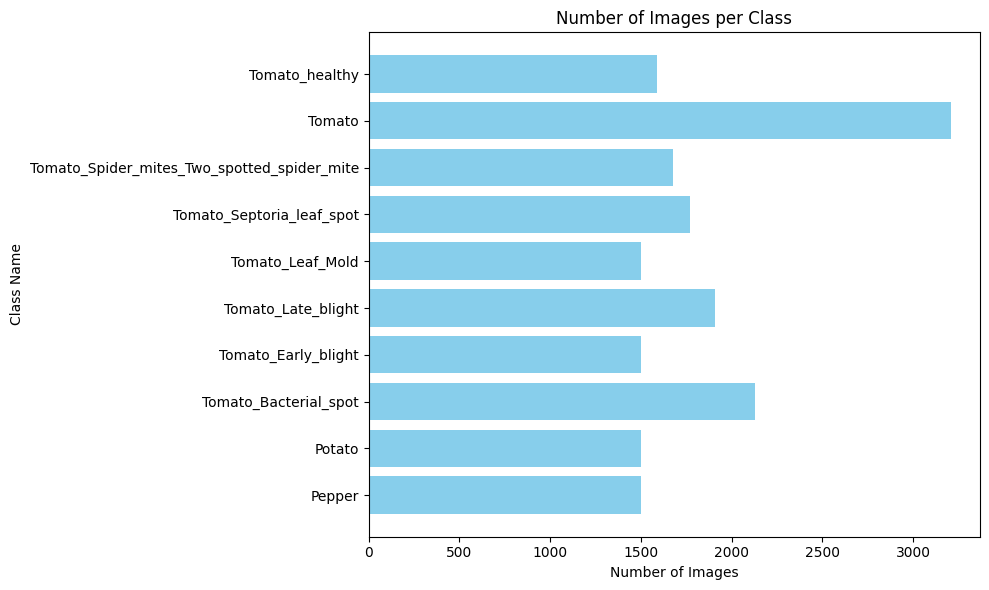

In [6]:

df_class_data['Short Class Name'] = df_class_data['Class Name'].apply(lambda x: x.split('__')[0])
plt.figure(figsize=(10, 6))
plt.barh(df_class_data['Short Class Name'], df_class_data['Number of Images'], color='skyblue')
plt.xlabel('Number of Images')
plt.ylabel('Class Name')
plt.title('Number of Images per Class')
plt.tight_layout()
plt.savefig('class_image_stats.png', dpi=300)
plt.show()

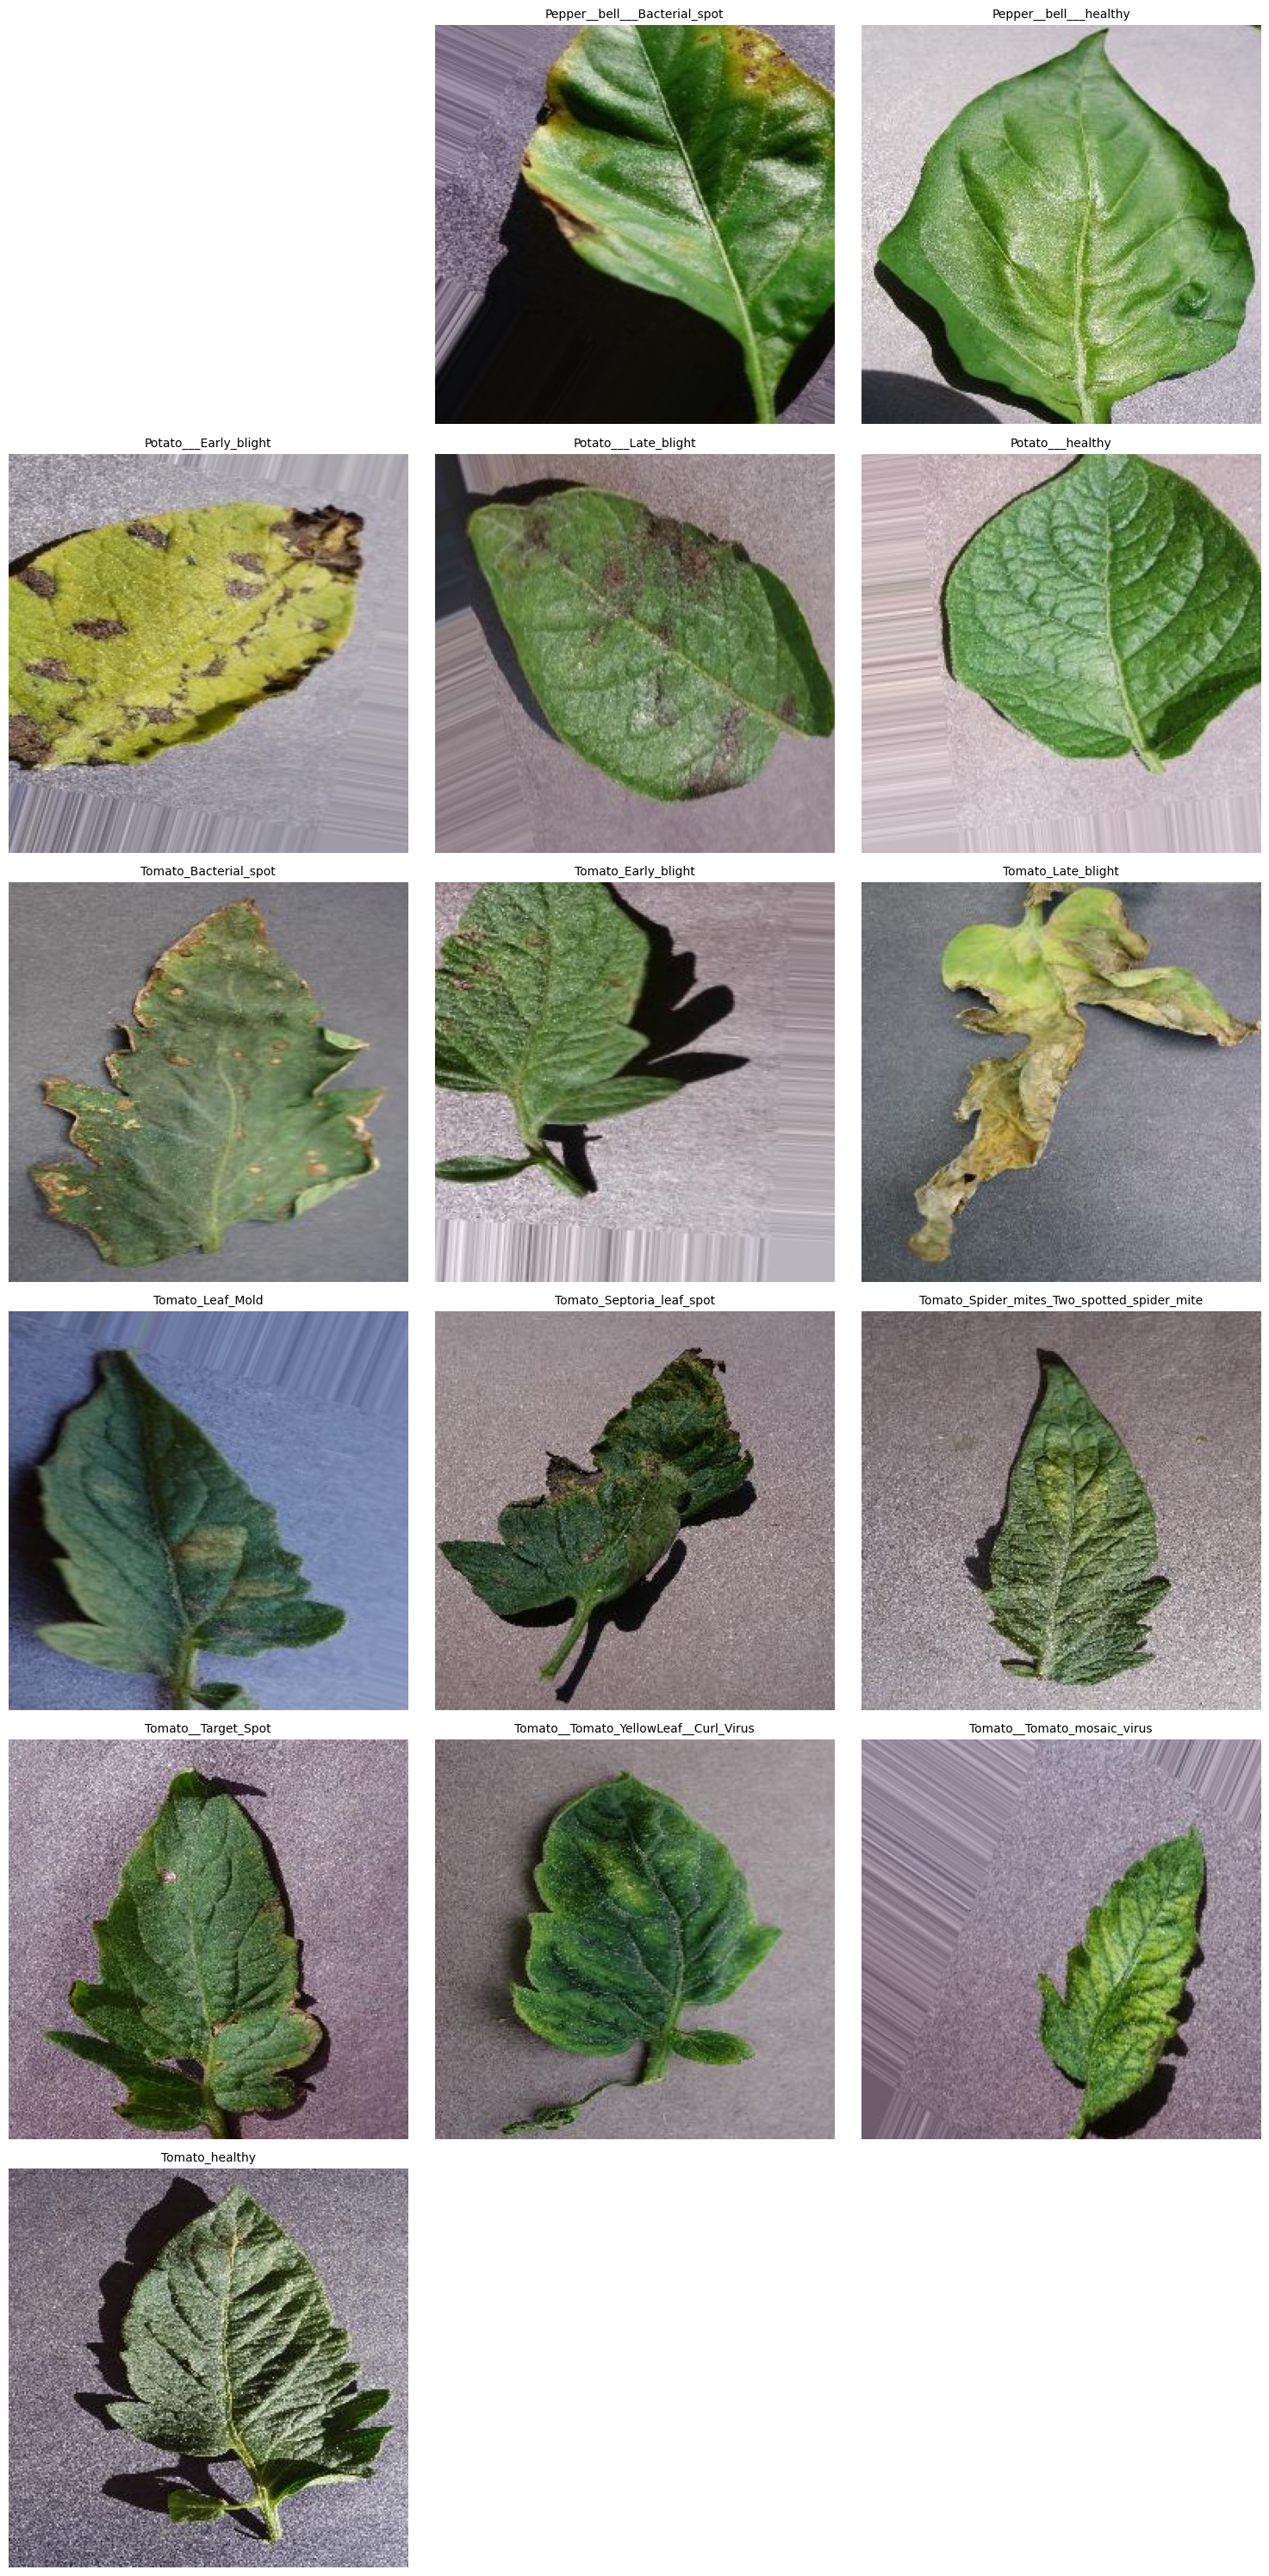

In [7]:
class_names = os.listdir(dataset_dir)
class_names.sort()


num_classes = len(class_names)
rows = (num_classes // 3) + (1 if num_classes % 3 != 0 else 0)

plt.figure(figsize=(15, rows * 5))

for i, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_dir, class_name)
    
    if os.path.isdir(class_path):
        image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        
        if image_files:
            image_path = os.path.join(class_path, image_files[0])
            image = cv2.imread(image_path)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            plt.subplot(rows, 3, i + 1)
            plt.imshow(image_rgb)
            plt.title(class_name, fontsize=10)
            plt.axis('off')

plt.tight_layout()
plt.show()